In [1]:
# 기본 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt


'''
[Step 1] 데이터 준비
'''

# Wholesale customers 데이터셋 가져오기 (출처: UCI ML Repository)
uci_path = 'https://archive.ics.uci.edu/ml/machine-learning-databases/\
00292/Wholesale%20customers%20data.csv'
df = pd.read_csv(uci_path, header=0)


'''
[Step 2] 데이터 탐색
'''

# 데이터 살펴보기
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
# 데이터 자료형 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [3]:
# 데이터 통계 요약정보 확인
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [4]:
# 누락 데이터 확인
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [5]:
# 중복 데이터 확인
df.duplicated().sum()

np.int64(0)

In [6]:
'''
[Step 3] 데이터 전처리
'''

# 분석에 사용할 속성을 선택
X = df.iloc[:, :]
print(X[:5])

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [7]:
# 설명 변수 데이터를 정규화
from sklearn import preprocessing
X_std = preprocessing.StandardScaler().fit_transform(X)

X_std[:5]

array([[ 1.44865163,  0.59066829,  0.05293319,  0.52356777, -0.04111489,
        -0.58936716, -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197,  0.54445767,  0.17031835,
        -0.27013618,  0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926,  0.40853771, -0.0281571 ,
        -0.13753572,  0.13323164,  2.24329255],
       [-0.69029709,  0.59066829,  0.10011141, -0.62401993, -0.3929769 ,
         0.6871443 , -0.49858822,  0.09341105],
       [ 1.44865163,  0.59066829,  0.84023948, -0.05239645, -0.07935618,
         0.17385884, -0.23191782,  1.29934689]])

In [8]:
'''
[Step 4] k-means 군집 모형 - sklearn 사용
'''

# sklearn 라이브러리에서 cluster 군집 모형 가져오기
from sklearn import cluster

# 모형 객체 생성 
kmeans = cluster.KMeans(init='k-means++', n_clusters=5, n_init=10)

# 모형 학습
kmeans.fit(X_std)   

# 예측 (군집) 
cluster_label = kmeans.labels_   
print(cluster_label)

[3 3 3 2 3 3 3 3 2 3 3 3 3 3 3 2 3 2 3 2 3 2 2 4 3 3 2 2 3 2 2 2 2 2 2 3 2
 3 3 2 2 2 3 3 3 3 3 0 3 3 2 2 3 3 2 2 0 3 2 2 3 0 3 3 2 0 2 3 2 2 2 2 2 3
 3 2 2 3 2 2 2 3 3 2 3 0 0 4 2 2 2 2 0 2 3 2 3 2 2 2 3 3 3 2 2 2 3 3 3 3 2
 3 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2
 2 2 2 2 2 2 2 3 3 2 3 3 3 2 2 3 3 3 3 2 2 2 3 3 2 3 2 3 2 2 2 2 2 4 2 4 2
 2 2 2 3 3 2 2 2 3 2 2 1 3 1 1 3 3 1 1 1 3 1 1 1 3 1 0 1 1 3 1 3 1 3 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 3 1 3 1 3 1 1 1 1 2 2 2 2 2 2 3 2 3 2 2 2 2 2 2 2 2 2 2 2 3 1 3
 1 3 3 1 3 3 3 3 3 3 3 1 1 3 1 1 3 1 1 3 1 1 1 3 1 1 1 1 1 4 1 1 1 1 1 3 1
 0 1 3 1 1 1 1 3 3 2 3 2 2 3 3 2 3 2 3 2 3 2 2 2 3 2 2 2 2 2 2 2 3 2 2 2 2
 3 2 2 3 2 2 3 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2 2 2 2 2
 3 3 2 2 2 2 2 2 3 3 2 3 2 2 3 2 3 3 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2]


In [9]:
# 예측 결과를 데이터프레임에 추가
df['Cluster'] = cluster_label
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,3
1,2,3,7057,9810,9568,1762,3293,1776,3
2,2,3,6353,8808,7684,2405,3516,7844,3
3,1,3,13265,1196,4221,6404,507,1788,2
4,2,3,22615,5410,7198,3915,1777,5185,3


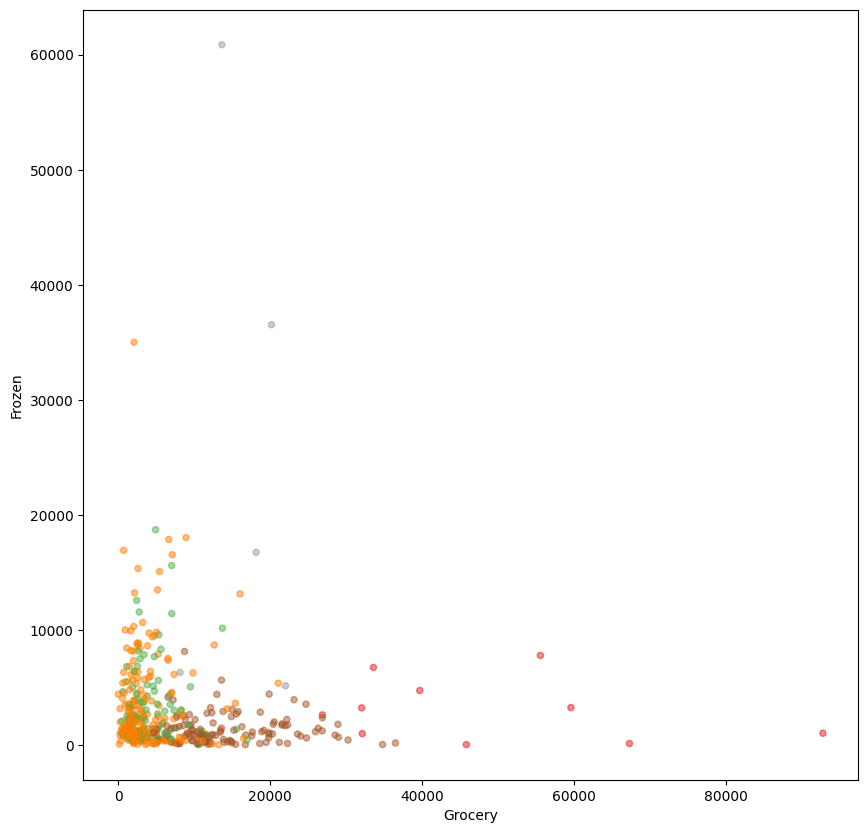

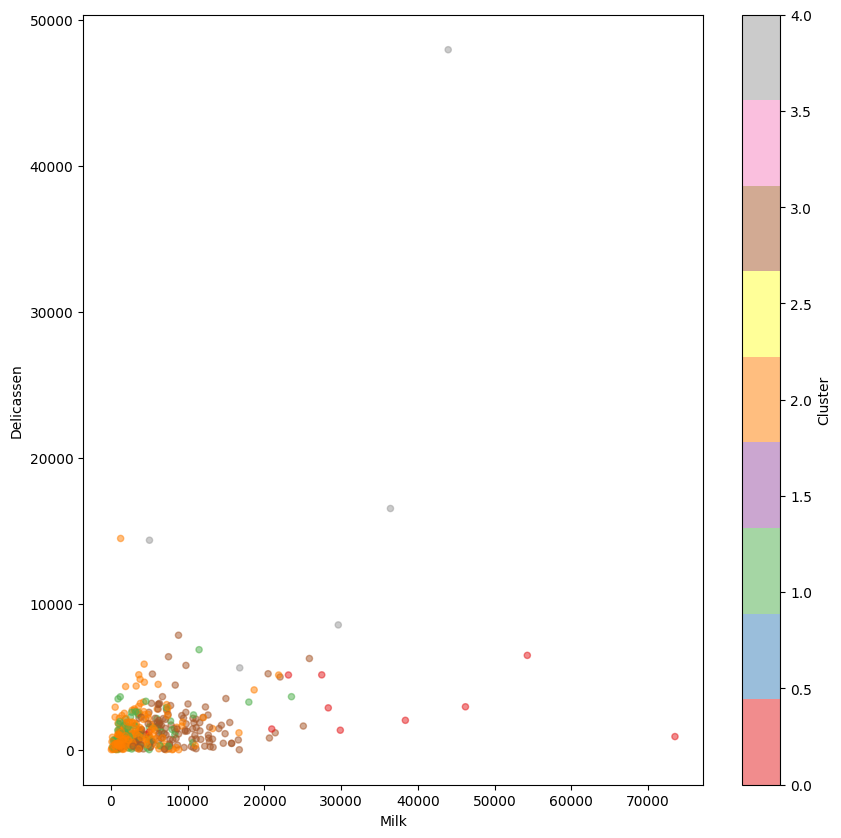

In [10]:
# 그래프로 표현 - 시각화
df.plot(kind='scatter', x='Grocery', y='Frozen', c='Cluster', cmap='Set1', 
        colorbar=False, alpha=0.5, figsize=(10, 10));
df.plot(kind='scatter', x='Milk', y='Delicassen', c='Cluster', cmap='Set1', 
        colorbar=True, alpha=0.5, figsize=(10, 10));

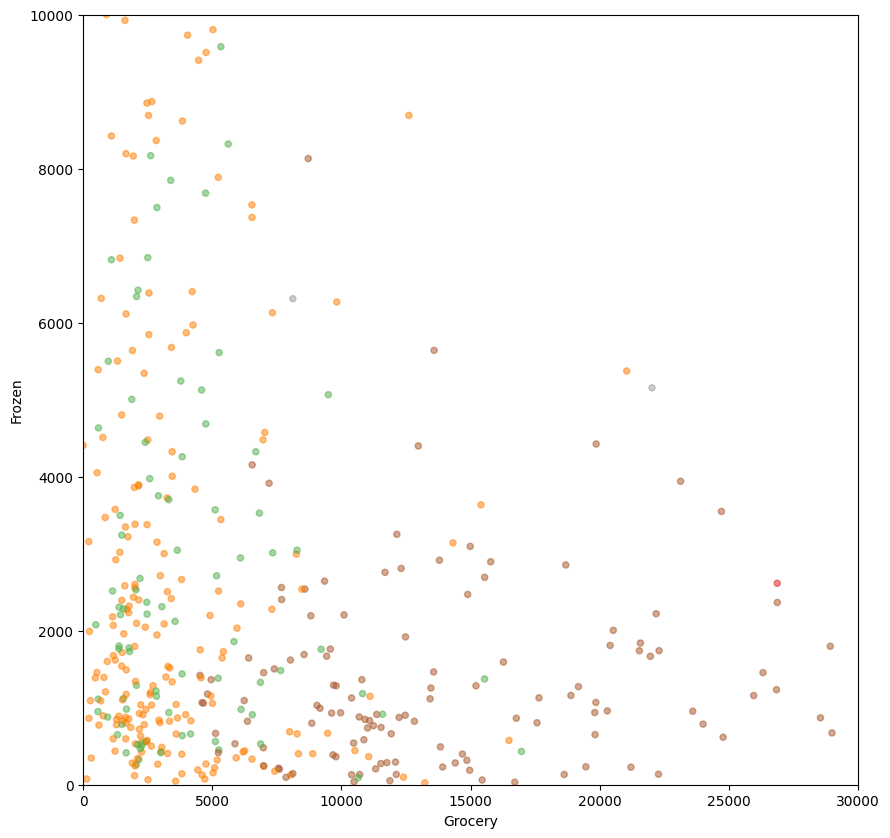

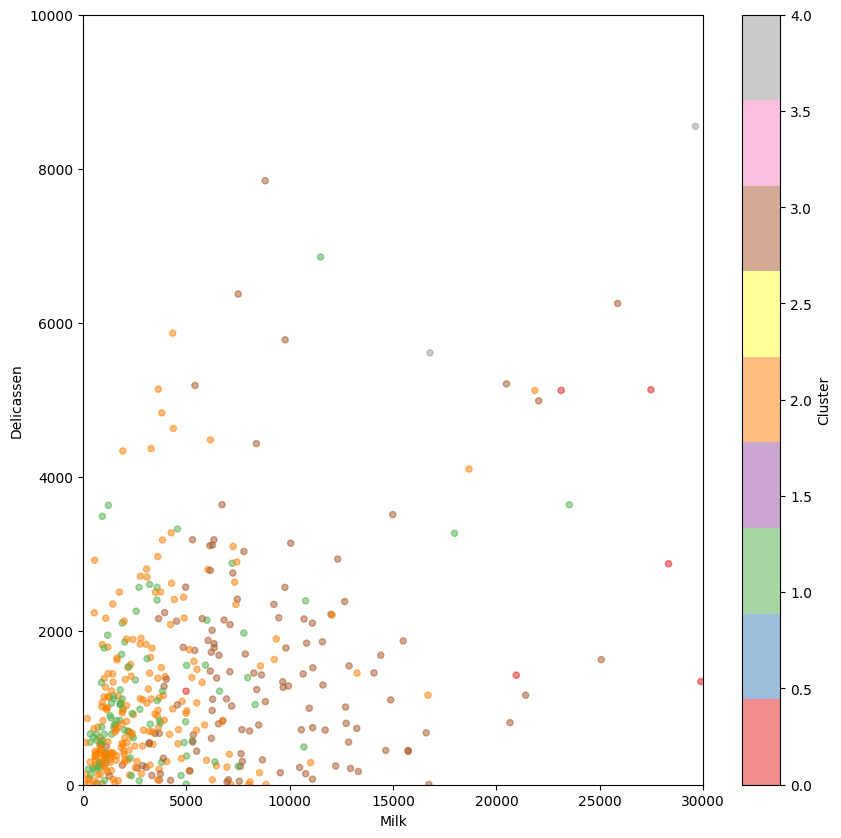

In [11]:
# xlim, ylim 제한 - 값이 몰려 있는 구간을 자세하게 분석
ax1 = df.plot(kind='scatter', x='Grocery', y='Frozen', c='Cluster', cmap='Set1', 
             colorbar=False, alpha=0.5, figsize=(10, 10))
ax2 = df.plot(kind='scatter', x='Milk', y='Delicassen', c='Cluster', cmap='Set1', 
             colorbar=True, alpha=0.5, figsize=(10, 10))
ax1.set_xlim(0, 30000)
ax1.set_ylim(0, 10000)
ax2.set_xlim(0, 30000)
ax2.set_ylim(0, 10000)
plt.show()